L. Parker and S. M. Christensen, *MathTensor: A System for Doing Tensor Analysis by Computer* (Addison-Wesley, 1994)

In [1]:
<< mTensor`

# Chapter 4. Components, Transformation, and Types of Indices

## 4.1 Components and Their Values

### 4.1.1 Integers as Indices

In [2]:
Tdefine[MaxwellF, "F", "-ba"]

텐서 성분 표현에서 contravariant 인덱스는 양의 정수, covariant 인덱스는 음의 정수를 사용한다.

In [3]:
{MaxwellF[-1, -4], MaxwellF[-4, -1], MaxwellF[4, 1]}

{MaxwellF[-1, -4], MaxwellF[-4, -1], MaxwellF[4, 1]}

시공간을 4차원으로 설정한다. 따라서 텐서 성분의 최대값은 4가 된다.

In [4]:
SetDimension[4]

벡터 `e`와 `x`를 정의한다:

In [5]:
Tdefine[e, 1]; Tdefine[x[ua]]

텐서 성분의 값을 지정한다:

In [6]:
SetComponents[MaxwellF[1, 4], -e[1]];
SetComponents[MaxwellF[2, 4], -e[2]];
SetComponents[MaxwellF[3, 4], -e[3]];
SetComponents[x[ua], {x, y, z, t}]

In [10]:
SetComponents[e[1], a Sin[t - z]]

In [11]:
BD[-3, MaxwellF[1, 4]]

-(a BD[-3, t] Cos[t - z]) + a BD[-3, z] Cos[t - z] - BD[-3, a] Sin[t - z]

좌표계를 설정하고 그 좌표계를 이용하여 보통 도함수의 값을 구하도록 한다:

In [12]:
SetCoordinates[{x, y, z, t}];
On[EvaluateBDFlag]

In [14]:
BD[-3, MaxwellF[1, 4]]

a Cos[t - z]

In [15]:
BD[-3, MaxwellF[2, 4]]

-BD[-3, e[2]]

In [16]:
Off[EvaluateBDFlag]  (* default *)

### 4.1.2 Using Integer and Symbolic Indices

설정된 텐서 성분의 값을 취소한다:

In [17]:
ClearComponents[e[1]]

가우스 법칙 $\partial_a F^{ab} = 0$:

In [18]:
gaussLaw = BD[la, MaxwellF[4, ua]]

BD[la, MaxwellF[4, ua]]

Contracted 인덱스의 성분 합을 구한다:

In [19]:
SumDum[gaussLaw] // TindexSort

BD[-3, e[3]] + BD[-2, e[2]] + BD[-1, e[1]]

전자기장의 자기장 성분과 메트릭 성분을 설정한다: 

In [20]:
Tdefine[b, 1]

In [21]:
SetComponents[MaxwellF[1, 2], b[3]];
SetComponents[MaxwellF[1, 3], -b[2]];
SetComponents[MaxwellF[2, 3], b[1]];

In [24]:
metric = {{1, 0, 0, 0}, {0, 1, 0, 0}, {0, 0, 1, 0}, {0, 0, 0, -1}};
SetComponents[Metricg[la, lb], metric]

전자기장 $F_{ab}$의 성분 표현:

In [26]:
Metricg[la, lc] Metricg[lb, ld] MaxwellF[uc, ud]

MaxwellF[uc, ud] Metricg[la, lc] Metricg[lb, ld]

In [27]:
dnF = Table[If[la === lb, 0, SumDum[%]],
             {la, -1, -4, -1}, {lb, -1, -4, -1}]

{{0, b[3], -b[2], e[1]}, {-b[3], 0, b[1], e[2]}, {b[2], -b[1], 0, e[3]}, 
 
>   {-e[1], -e[2], -e[3], 0}}

In [28]:
SetComponents[MaxwellF[la, lb], dnF]

0       b[3]    -b[2]   e[1]

-b[3]   0       b[1]    e[2]

b[2]    -b[1]   0       e[3]

-e[1]   -e[2]   -e[3]   0
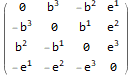

In [29]:
Table[MaxwellF[-i, -j], {i, 4}, {j, 4}] // MatrixForm

In [30]:
{MaxwellF[-1, -4], MaxwellF[-2, -3], MaxwellF[-1, -2]}

{e[1], b[1], b[3]}

전자기장 $F_{ab}$의 성분 표현 (다른 방법):

In [31]:
F2[la_, lb_] := 
 SumDum[Metricg[la, lc] Metricg[lb, ld] MaxwellF[uc, ud]]

In [32]:
{F2[-1, -4], F2[-2, -3], F2[-1, -2]}

{e[1], b[1], b[3]}

전자기장 방정식:

In [33]:
eq1[lb_, ua_, ub_] := BD[lb, MaxwellF[ua, ub]] /; PairIndexQ[lb, ub]
eq1[lb, ua, ub]

BD[lb, MaxwellF[ua, ub]]

In [35]:
eq2[la_, lb_, lc_] := 
 BD[la, MaxwellF[lb, lc]] + BD[lb, MaxwellF[lc, la]] + 
  BD[lc, MaxwellF[la, lb]];
eq2[la, lb, lc]

BD[la, MaxwellF[lb, lc]] + BD[lb, MaxwellF[lc, la]] + BD[lc, MaxwellF[la, lb]]

In [37]:
SumDum[eq1[lb, 1, ub]] // TindexSort

-BD[-4, e[1]] - BD[-3, b[2]] + BD[-2, b[3]]

In [38]:
SumDum[eq1[lb, 2, ub]] // TindexSort

-BD[-4, e[2]] + BD[-3, b[1]] - BD[-1, b[3]]

In [39]:
SumDum[eq1[lb, 3, ub]] // TindexSort

-BD[-4, e[3]] - BD[-2, b[1]] + BD[-1, b[2]]

In [40]:
SumDum[eq1[lb, 4, ub]] // TindexSort

BD[-3, e[3]] + BD[-2, e[2]] + BD[-1, e[1]]

In [41]:
eq2[-1, -2, -3] // TindexSort

BD[-3, b[3]] + BD[-2, b[2]] + BD[-1, b[1]]

In [42]:
eq2[-1, -2, -4] // TindexSort

BD[-4, b[3]] - BD[-2, e[1]] + BD[-1, e[2]]

전자기장 텐서의 불변량:

In [43]:
MaxwellF[la, lb] MaxwellF[ua, ub]

MaxwellF[la, lb] MaxwellF[ua, ub]

In [44]:
SumDum[{la, -4, li}, {lb, -4, lj}, %] // TindexSort

MaxwellF[li, -4] MaxwellF[ui, 4] + MaxwellF[li, lj] MaxwellF[ui, uj] + 
 
>   MaxwellF[lj, -4] MaxwellF[uj, 4]

In [45]:
SumDum[{1, 3}, %] // TindexSort

2         2         2         2         2         2
2 b[1]  + 2 b[2]  + 2 b[3]  - 2 e[1]  - 2 e[2]  - 2 e[3]

전자기장 $F_{ab}$에 설정된 성분값을 취소한다:

In [46]:
ClearComponents[MaxwellF[la, lb]]

In [47]:
{MaxwellF[-2, -1], MaxwellF[1, 3]}

{MaxwellF[-2, -1], -b[2]}

In [48]:
{MaxwellF[-1, -1], MaxwellF[-1, -2]} // TindexSort

{0, MaxwellF[-1, -2]}

### 4.1.3 Flat Metric in Cartesian Coordinates

시공간의 메트릭을 민코프스키 메트릭으로 설정한다:

In [2]:
MakeConstantMetric[{-1, 1, 1, 1}]

-1   0    0    0

0    1    0    0

0    0    1    0

0    0    0    1
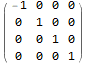

In [3]:
Table[Metricg[-i, -j], {i, 4}, {j, 4}] // MatrixForm

시공간의 메트릭을 3차원 유클리드 메트릭으로 설정한다:

In [4]:
MakeConstantMetric[{1, 1, 1}]

1   0   0

0   1   0

0   0   1
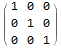

In [5]:
Table[Metricg[-i, -j], {i, 3}, {j, 3}] // MatrixForm

In [6]:
SetCoordinates[{x, y, z}]

In [7]:
On[EvaluateBDFlag]

In [8]:
BD[-1, -3, (x y z)^2]

2
4 x y  z

In [9]:
Off[EvaluateBDFlag]  (* default *)

### 4.1.4 Calculating the Components of Curvature Tensors

#### Schwarzschild SpaceTime

In [10]:
coSys = {r, \[Theta], \[Phi], t}

{r, θ, ϕ, t}

1                     2                 2       2                     2 G M
{{---------, 0, 0, 0}, {0, r , 0, 0}, {0, 0, r  Sin[θ] , 0}, {0, 0, 0, -1 + -----}}
      2 G M                                                                   r
  1 - -----
        r
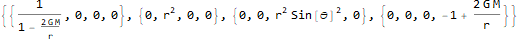

In [11]:
metric = {{1/(1 - (2 G M)/r), 0, 0, 0},
           {0, r^2, 0, 0},
           {0, 0, r^2 Sin[\[Theta]]^2, 0},
           {0, 0, 0, -(1 - (2 G M)/r)}}

In [13]:
Det[metric] // Simplify

4       2
-(r  Sin[θ] )

주어진 좌표계와 메트릭으로 텐서의 성분 연산을 위한 준비를 한다:

In [12]:
InitCTensor[coSys, metric, RicciCD -> True]

연산 결과값들을 표시하자:

G M
-------------
(2 G M - r) r
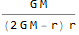

In [14]:
GammaCD[-1, -1, 1]

G M
---------
2 G M - r
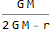

In [15]:
RiemannCD[-1, -2, -1, -2]

In [16]:
RicciCD[-1, -1]

0

Weyl 텐서의 성분값을 구한다:

In [17]:
Tcalc[WeylCD]

G M
---------
2 G M - r
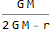

In [18]:
WeylCD[-1, -2, -1, -2] // Simplify

#### Robertson-Walker SpaceTime

In [19]:
coSys = {x, y, z, t}

{x, y, z, t}

In [20]:
metric = {{a[t]^2, 0, 0, 0},
           {0, a[t]^2, 0, 0},
           {0, 0, a[t]^2, 0},
           {0, 0, 0, -1}}

2                    2                    2
{{a[t] , 0, 0, 0}, {0, a[t] , 0, 0}, {0, 0, a[t] , 0}, {0, 0, 0, -1}}

In [21]:
InitCTensor[coSys, metric, RicciCD -> True]

In [22]:
RiemannCD[-1, -2, -1, -2]

2      2
a[t]  a'[t]

In [23]:
RicciCD[-1, -1]

2
2 a'[t]  + a[t] a''[t]

In [24]:
Metricg[1, ua] RicciCD[-1, la]

Metricg[1, ua] RicciCD[-1, la]

2
2 a'[t]  + a[t] a''[t]
----------------------
            2
        a[t]
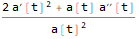

In [25]:
% // SumDum

2
6 (a'[t]  + a[t] a''[t])
------------------------
             2
         a[t]
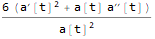

In [26]:
ScalarCD[]

In [27]:
Tcalc[WeylCD]

In [28]:
WeylCD[-1, -2, -1, -2]

0

### 4.1.5 Invariants from Curvature Components

Robertson-Walker 시공간의 곡률 텐서로 구성된 불변량을 계산한다.

In [29]:
Metricg[ua, uc] Metricg[ub, ud] RicciCD[la, lb] RicciCD[lc, ld]

Metricg[ua, uc] Metricg[ub, ud] RicciCD[la, lb] RicciCD[lc, ld]

4             2              2       2
12 (a'[t]  + a[t] a'[t]  a''[t] + a[t]  a''[t] )
------------------------------------------------
                         4
                     a[t]
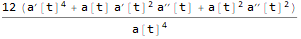

In [30]:
ricciSquared = SumDum[%] // Expand // Together

2               2
36 (a'[t]  + a[t] a''[t])
--------------------------
              4
          a[t]
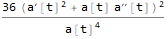

In [31]:
scalarSquared = ScalarCD[]^2

$R^{abcd}$의 성분값을 $R_{abcd}$로부터 구한다:

In [34]:
Metricg[ua, ue] Metricg[ub, uf] Metricg[uc, ug] Metricg[ud, 
       uh] RiemannCD[le, lf, lg, lh]

Metricg[ua, ue] Metricg[ub, uf] Metricg[uc, ug] Metricg[ud, uh] RiemannCD[le, lf, lg, lh]

In [35]:
Timing[riemannUp = Table[SumDum[%],
                           {ua, 4}, {ub, 4},
                           {uc, 4}, {ud, 4}];]

{0.328125, Null}

In [36]:
SetComponents[RiemannCD[ua, ub, uc, ud], riemannUp]

곡률 불변량을 계산한다:

In [37]:
RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, uc, ud]

RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, uc, ud]

4            2
12 a'[t]    12 a''[t]
--------- + ----------
      4           2
  a[t]        a[t]
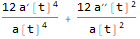

In [38]:
riemannSquared = SumDum[%]

$\sqrt{-g} (R_{abcd} R^{abcd} + R^2 - 4R_{ab} R^{ab})$ 계산:

In [39]:
gaussBonnet = 
 Sqrt[-Det[metric]] (riemannSquared + scalarSquared - 
      4 ricciSquared) // Simplify // PowerExpand

2
24 a'[t]  a''[t]

In [44]:
gaussBonnet == 8 D[a'[t]^3, t]

True

### 4.1.6 Simplication and Series Expansion in Components

성분 연산에서 사용되는 규칙을 `CsimplifyRules`에 설정할 수 있다. 디폴트는 `{}`이다.

매개 변수 $q$에 대한 근사 계산으로 Series Expansion을 한다고 할 때 설정하는 성분 연산 단순화 함수 `Csimplify`:

In [50]:
Csimplify[expr_] := Series[Expand[expr /. CsimplifyRules], {q, 0, 2}]

무한대 근방에서 $1/r$의 3차항까지 점근 연산을 한다고 할 때 설정하는 `Csimplify`:

In [51]:
Csimplify[expr_] := 
 Together[Series[Expand[expr /. CsimplifyRules], {r, Infinity, 3}]]

디폴트 `Csimplify`:

In [52]:
Csimplify[expr_] := Together[expr /. CsimplifyRules] /. CsimplifyRules

### 4.1.7 Schwarzschild with Alternate Simplication

텐서 성분 연산을 위한 단순화 명령을 설정한다:

In [53]:
SetOptions[Together, Trig -> False];
Csimplify[expr_] := Together[expr /. CsimplifyRules]

구형 좌표계에서 슈바르츠실트 메트릭으로 성분 연산을 위한 초기화 설정을 한다:

In [55]:
coSys = {r, \[Theta], \[Phi], t};
metric = {{1/(1 - (2 G M)/r), 0, 0, 0},
           {0, r^2, 0, 0},
           {0, 0, r^2 Sin[\[Theta]]^2, 0},
           {0, 0, 0, -(1 - (2 G M)/r)}};

In [57]:
InitCTensor[coSys, metric, RicciCD -> True]

초기화 설정 후의 결과값들을 출력한다:

2
  -2 G M + r                 -2                Csc[θ]                     r
{{----------, 0, 0, 0}, {0, r  , 0, 0}, {0, 0, -------, 0}, {0, 0, 0, ---------}}
      r                                           2                   2 G M - r
                                                 r
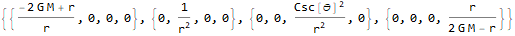

In [58]:
Table[Metricg[ua, ub], {ua, 4}, {ub, 4}]

In [59]:
Table[RicciCD[-i, -i], {i, 4}, {j, i}] // Simplify

{{0}, {0, 0}, {0, 0, 0}, {0, 0, 0, 0}}

2
     G M       G M Sin[θ]                 2
{{---------}, {-----------, 2 G M r Sin[θ] }, 
  2 G M - r     2 G M - r
 
                                                         2
     -2 G M    G M (2 G M - r)     G M (2 G M - r) Sin[θ]
>   {------, -(---------------), -(-----------------------)}}
        3             2                       2
       r             r                       r
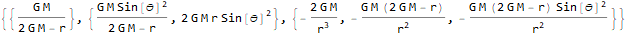

In [60]:
Table[RiemannCD[-i, -j, -i, -j], {i, 2, 4}, {j, i - 1}]

리만 텐서의 불변량 $R_{abcd} R^{abcd}$를 계산한다:

In [61]:
Metricg[ua, ue] Metricg[ub, uf] Metricg[uc, ug] Metricg[ud, 
  uh] RiemannCD[le, lf, lg, lh]

Metricg[ua, ue] Metricg[ub, uf] Metricg[uc, ug] Metricg[ud, uh] RiemannCD[le, lf, lg, lh]

In [62]:
Timing[riemannUp = 
   Table[SumDum[%], {ua, 4}, {ub, 4}, {uc, 4}, {ud, 4}];]

{0.34375, Null}

In [63]:
SetComponents[RiemannCD[ua, ub, uc, ud], riemannUp]

In [64]:
RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, uc, ud]

RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, uc, ud]

2  2
48 G  M
--------
    6
   r
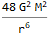

In [65]:
SumDum[%] // Simplify

### 4.1.8 Asymptotic Behavior in Schwarzschild

텐서 성분 연산을 위한 단순화 명령을 무한대에서의 점근 근사로 설정한다:

In [66]:
SetOptions[Expand, Trig -> True];
Csimplify[expr_] := 
 Simplify[Series[Expand[expr /. CsimplifyRules], {r, Infinity, 3}]]

구형 좌표계에서 슈바르츠실트 메트릭으로 성분 연산을 위한 초기화 설정을 한다:

In [68]:
coSys = {r, \[Theta], \[Phi], t};
metric = {{1/(1 - (2 G M)/r), 0, 0, 0},
           {0, r^2, 0, 0},
           {0, 0, r^2 Sin[\[Theta]]^2, 0},
           {0, 0, 0, -(1 - (2 G M)/r)}};

In [70]:
InitCTensor[coSys, metric, RicciCD -> True]

초기화 설정 후의 결과값들을 출력한다:

2
      2 G M       -4        -2       -4          Csc[θ]        -4
{{1 - ----- + O[r]  }, {0, r   + O[r]  }, {0, 0, ------- + O[r]  }, 
        r                                           2
                                                   r
 
                              2  2      3  3
                   2 G M   4 G  M    8 G  M        -4
>   {0, 0, 0, -1 - ----- - ------- - ------- + O[r]  }}
                     r        2         3
                             r         r
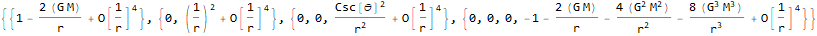

In [71]:
Table[Metricg[i, j], {i, 4}, {j, i}]

-4        -3      -2              -2                 -4
{{O[r]  }, {O[r]  , O[r]  }, {0, 0, O[r]  }, {0, 0, 0, O[r]  }}
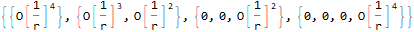

In [72]:
Table[RicciCD[-i, -j], {i, 4}, {j, i}]

In [73]:
% // Normal

{{0}, {0, 0}, {0, 0, 0}, {0, 0, 0, 0}}

2
    G M        -2      G M Sin[θ]         -2                2       0
{{-(---) + O[r]  }, {-(-----------) + O[r]  , 2 G M r Sin[θ]  + O[r] }, 
     r                      r
 
                               2  2                     2      2  2       2
     -2 G M       -4  G M   2 G  M        -3  G M Sin[θ]    2 G  M  Sin[θ]        -3
>   {------ + O[r]  , --- - ------- + O[r]  , ----------- - --------------- + O[r]  }}
        3              r       2                   r               2
       r                      r                                   r
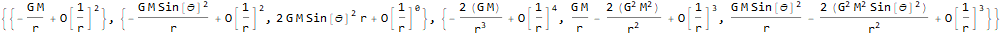

In [74]:
Table[RiemannCD[-i, -j, -i, -j], {i, 2, 4}, {j, i - 1}]

### 4.1.9 Perturbations of Flat Spacetime

텐서 성분 연산을 위한 단순화 명령을 민코프스키 시공간에 대한 섭동으로 설정한다:

In [75]:
SetOptions[Expand, Trig -> False];
Csimplify[expr_] := 
 Together[Series[Expand[expr /. CsimplifyRules], {\[Epsilon], 0, 1}]]

직교 좌표계에서 민코프스키 시공간의 섭동을 묘사하는 메트릭으로 성분 연산을 위한 초기화 설정을 한다:

$$
  g_{ab} = \pmatrix{
    1 + \epsilon h_{11}[t] & \epsilon h_{12}[t]
    & \epsilon h_{13}[t] & \epsilon h_{14}[t] \\
    \epsilon h_{12}[t] & 1 + \epsilon h_{22}[t]
    & \epsilon h_{23}[t] & \epsilon h_{24}[t] \\
    \epsilon h_{13}[t] & \epsilon h_{23}[t]
    & 1 + \epsilon h_{33}[t] & \epsilon h_{34}[t] \\
    \epsilon h_{14}[t] & \epsilon h_{24}[t]
    & \epsilon h_{23}[t] & -1 + \epsilon h_{44}[t]}
$$

In [77]:
coSys = {x, y, z, t};
metric = {{1 + \[Epsilon] h11[t], \[Epsilon] h12[t],
            \[Epsilon] h13[t], \[Epsilon] h14[t]},
          {\[Epsilon] h12[t], 1 + \[Epsilon] h22[t],
            \[Epsilon] h23[t], \[Epsilon] h24[t]},
          {\[Epsilon] h13[t], \[Epsilon] h23[t],
            1 + \[Epsilon] h33[t], \[Epsilon] h34[t]},
          {\[Epsilon] h14[t], \[Epsilon] h24[t],
            \[Epsilon] h23[t], -1 + \[Epsilon] h44[t]}};

In [79]:
InitCTensor[coSys, metric, RicciCD -> True]

초기화 설정 후의 결과값들을 출력한다:

ϵ h11''[t]       2    ϵ h12''[t]       2  ϵ h22''[t]       2
{{---------- + O[ϵ] }, {---------- + O[ϵ] , ---------- + O[ϵ] }, 
      2                     2                   2
 
     ϵ h13''[t]       2  ϵ h23''[t]       2  ϵ h33''[t]       2
>   {---------- + O[ϵ] , ---------- + O[ϵ] , ---------- + O[ϵ] }, 
         2                   2                   2
 
         2      2      2  ϵ (-h11''[t] - h22''[t] - h33''[t])       2
>   {O[ϵ] , O[ϵ] , O[ϵ] , ----------------------------------- + O[ϵ] }}
                                           2
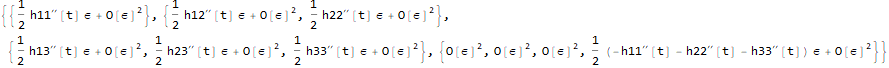

In [80]:
Table[RicciCD[-i, -j], {i, 4}, {j, i}]

In [81]:
ScalarCD[]

2
(h11''[t] + h22''[t] + h33''[t]) ϵ + O[ϵ]

2      2  -(ϵ h33''[t])       2
{O[ϵ] , O[ϵ] , ------------- + O[ϵ] }
                     2
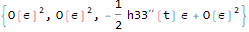

In [82]:
Table[RiemannCD[-i, -i - 1, -i, -i - 1], {i, 1, 3}]

리치 텐서의 불변량 $R_{ab} R^{ab}$를 계산한다:

In [83]:
Metricg[ua, uc] Metricg[ub, ud] RicciCD[la, lb] RicciCD[lc, ld]

Metricg[ua, uc] Metricg[ub, ud] RicciCD[la, lb] RicciCD[lc, ld]

In [84]:
% // SumDum

2
O[ϵ]

### 4.1.10 Evaluating General Tensor Expressions for Particular Metrics

텐서 성분 연산을 위해 실행한 `InitCTensor` 명령을 취소하는 함수는 (아직까지는) 없다. 따라서 다른 메트릭을 갖는 시공간에 대한 성분 연산을 새로 하려면 `Mathematica`를 재시작하고, `mTensor`를 다시 로드해야 한다:

In [1]:
<< mTensor`

성분 연산을 할 텐서 표현:

2 CD[la, CD[lb, ScalarCD[]]] - 2 CD[uc, CD[lc, ScalarCD[]]] Metricg[la, lb] + 
 
                                                             2
                                   Metricg[la, lb] ScalarCD[]
>   2 RicciCD[la, lb] ScalarCD[] - ---------------------------
                                                2
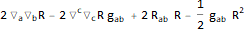

In [2]:
2 CD[la, lb, ScalarCD[]] - 1/2 ScalarCD[]^2 Metricg[la, lb] - 
 2 CD[uc, lc, ScalarCD[]] Metricg[la, lb] + 
 2 ScalarCD[] RicciCD[la, lb]

2 BD[la, CD[lb, ScalarCD[]]] - 2 CD[lc, ScalarCD[]] GammaCD[la, lb, uc] - 
 
>   2 BD[uc, CD[lc, ScalarCD[]]] Metricg[la, lb] + 
 
>   2 CD[ld, ScalarCD[]] GammaCD[uc, lc, ud] Metricg[la, lb] + 
 
                                                             2
                                   Metricg[la, lb] ScalarCD[]
>   2 RicciCD[la, lb] ScalarCD[] - ---------------------------
                                                2
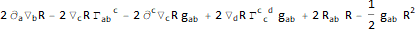

In [3]:
% // CDtoGamma

2 BD[la, BD[lb, ScalarCD[]]] - 2 BD[lc, ScalarCD[]] GammaCD[la, lb, uc] - 
 
>   2 BD[uc, BD[lc, ScalarCD[]]] Metricg[la, lb] + 
 
>   2 BD[ld, ScalarCD[]] GammaCD[uc, lc, ud] Metricg[la, lb] + 
 
                                                             2
                                   Metricg[la, lb] ScalarCD[]
>   2 RicciCD[la, lb] ScalarCD[] - ---------------------------
                                                2
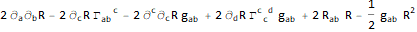

In [4]:
% // CDtoGamma

2 BD[la, BD[lb, ScalarCD[]]] - 2 BD[lc, ScalarCD[]] GammaCD[la, lb, ld] 
 
>    Metricg[uc, ud] - 2 BD[ld, BD[lc, ScalarCD[]]] Metricg[la, lb] Metricg[uc, ud] + 
 
>   2 BD[ld, ScalarCD[]] GammaCD[le, lc, ud] Metricg[la, lb] Metricg[uc, ue] + 
 
                                                             2
                                   Metricg[la, lb] ScalarCD[]
>   2 RicciCD[la, lb] ScalarCD[] - ---------------------------
                                                2
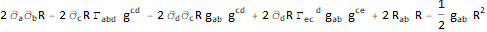

In [5]:
PutMetric[%, uc]

2 BD[la, BD[lb, ScalarCD[]]] - 2 BD[-1, ScalarCD[]] GammaCD[la, lb, -1] Metricg[1, 1] - 
 
>   2 BD[-1, ScalarCD[]] GammaCD[la, lb, -2] Metricg[1, 2] - 
 
>   2 BD[-1, ScalarCD[]] GammaCD[la, lb, -3] Metricg[1, 3] - 
 
>   2 BD[-1, ScalarCD[]] GammaCD[la, lb, -4] Metricg[1, 4] - 
 
>   2 BD[-2, ScalarCD[]] GammaCD[la, lb, -1] Metricg[2, 1] - 
 
>   2 BD[-2, ScalarCD[]] GammaCD[la, lb, -2] Metricg[2, 2] - 
 
>   2 BD[-2, ScalarCD[]] GammaCD[la, lb, -3] Metricg[2, 3] - 
 
>   2 BD[-2, ScalarCD[]] GammaCD[la, lb, -4] Metricg[2, 4] - 
 
>   2 BD[-3, ScalarCD[]] GammaCD[la, lb, -1] Metricg[3, 1] - 
 
>   2 BD[-3, ScalarCD[]] GammaCD[la, lb, -2] Metricg[3, 2] - 
 
>   2 BD[-3, ScalarCD[]] GammaCD[la, lb, -3] Metricg[3, 3] - 
 
>   2 BD[-3, ScalarCD[]] GammaCD[la, lb, -4] Metricg[3, 4] - 
 
>   2 BD[-4, ScalarCD[]] GammaCD[la, lb, -1] Metricg[4, 1] - 
 
>   2 BD[-4, ScalarCD[]] GammaCD[la, lb, -2] Metricg[4, 2] - 
 
>   2 BD[-4, ScalarCD[]] GammaCD[la, lb, -3] Metricg[4, 3] - 
 
>   2 BD[-4, ScalarCD[]] GammaCD[la, lb, -4] Metricg[4, 4] - 
 
>   2 BD[-1, BD[-1, ScalarCD[]]] Metricg[1, 1] Metricg[la, lb] + 
 
>   2 BD[-1, ScalarCD[]] GammaCD[-1, -1, 1] Metricg[1, 1] Metricg[la, lb] + 
 
>   2 BD[-2, ScalarCD[]] GammaCD[-1, -1, 2] Metricg[1, 1] Metricg[la, lb] + 
 
>   2 BD[-3, ScalarCD[]] GammaCD[-1, -1, 3] Metricg[1, 1] Metricg[la, lb] + 
 
>   2 BD[-4, ScalarCD[]] GammaCD[-1, -1, 4] Metricg[1, 1] Metricg[la, lb] - 
 
>   2 BD[-2, BD[-1, ScalarCD[]]] Metricg[1, 2] Metricg[la, lb] + 
 
>   2 BD[-1, ScalarCD[]] GammaCD[-2, -1, 1] Metricg[1, 2] Metricg[la, lb] + 
 
>   2 BD[-2, ScalarCD[]] GammaCD[-2, -1, 2] Metricg[1, 2] Metricg[la, lb] + 
 
>   2 BD[-3, ScalarCD[]] GammaCD[-2, -1, 3] Metricg[1, 2] Metricg[la, lb] + 
 
>   2 BD[-4, ScalarCD[]] GammaCD[-2, -1, 4] Metricg[1, 2] Metricg[la, lb] - 
 
>   2 BD[-3, BD[-1, ScalarCD[]]] Metricg[1, 3] Metricg[la, lb] + 
 
>   2 BD[-1, ScalarCD[]] GammaCD[-3, -1, 1] Metricg[1, 3] Metricg[la, lb] + 
 
>   2 BD[-2, ScalarCD[]] GammaCD[-3, -1, 2] Metricg[1, 3] Metricg[la, lb] + 
 
>   2 BD[-3, ScalarCD[]] GammaCD[-3, -1, 3] Metricg[1, 3] Metricg[la, lb] + 
 
>   2 BD[-4, ScalarCD[]] GammaCD[-3, -1, 4] Metricg[1, 3] Metricg[la, lb] - 
 
>   2 BD[-4, BD[-1, ScalarCD[]]] Metricg[1, 4] Metricg[la, lb] + 
 
>   2 BD[-1, ScalarCD[]] GammaCD[-4, -1, 1] Metricg[1, 4] Metricg[la, lb] + 
 
>   2 BD[-2, ScalarCD[]] GammaCD[-4, -1, 2] Metricg[1, 4] Metricg[la, lb] + 
 
>   2 BD[-3, ScalarCD[]] GammaCD[-4, -1, 3] Metricg[1, 4] Metricg[la, lb] + 
 
>   2 BD[-4, ScalarCD[]] GammaCD[-4, -1, 4] Metricg[1, 4] Metricg[la, lb] - 
 
>   2 BD[-1, BD[-2, ScalarCD[]]] Metricg[2, 1] Metricg[la, lb] + 
 
>   2 BD[-1, ScalarCD[]] GammaCD[-1, -2, 1] Metricg[2, 1] Metricg[la, lb] + 
 
>   2 BD[-2, ScalarCD[]] GammaCD[-1, -2, 2] Metricg[2, 1] Metricg[la, lb] + 
 
>   2 BD[-3, ScalarCD[]] GammaCD[-1, -2, 3] Metricg[2, 1] Metricg[la, lb] + 
 
>   2 BD[-4, ScalarCD[]] GammaCD[-1, -2, 4] Metricg[2, 1] Metricg[la, lb] - 
 
>   2 BD[-2, BD[-2, ScalarCD[]]] Metricg[2, 2] Metricg[la, lb] + 
 
>   2 BD[-1, ScalarCD[]] GammaCD[-2, -2, 1] Metricg[2, 2] Metricg[la, lb] + 
 
>   2 BD[-2, ScalarCD[]] GammaCD[-2, -2, 2] Metricg[2, 2] Metricg[la, lb] + 
 
>   2 BD[-3, ScalarCD[]] GammaCD[-2, -2, 3] Metricg[2, 2] Metricg[la, lb] + 
 
>   2 BD[-4, ScalarCD[]] GammaCD[-2, -2, 4] Metricg[2, 2] Metricg[la, lb] - 
 
>   2 BD[-3, BD[-2, ScalarCD[]]] Metricg[2, 3] Metricg[la, lb] + 
 
>   2 BD[-1, ScalarCD[]] GammaCD[-3, -2, 1] Metricg[2, 3] Metricg[la, lb] + 
 
>   2 BD[-2, ScalarCD[]] GammaCD[-3, -2, 2] Metricg[2, 3] Metricg[la, lb] + 
 
>   2 BD[-3, ScalarCD[]] GammaCD[-3, -2, 3] Metricg[2, 3] Metricg[la, lb] + 
 
>   2 BD[-4, ScalarCD[]] GammaCD[-3, -2, 4] Metricg[2, 3] Metricg[la, lb] - 
 
>   2 BD[-4, BD[-2, ScalarCD[]]] Metricg[2, 4] Metricg[la, lb] + 
 
>   2 BD[-1, ScalarCD[]] GammaCD[-4, -2, 1] Metricg[2, 4] Metricg[la, lb] + 
 
>   2 BD[-2, ScalarCD[]] GammaCD[-4, -2, 2] Metricg[2, 4] Metricg[la, lb] + 
 
>   2 BD[-3, ScalarCD[]] GammaCD[-4
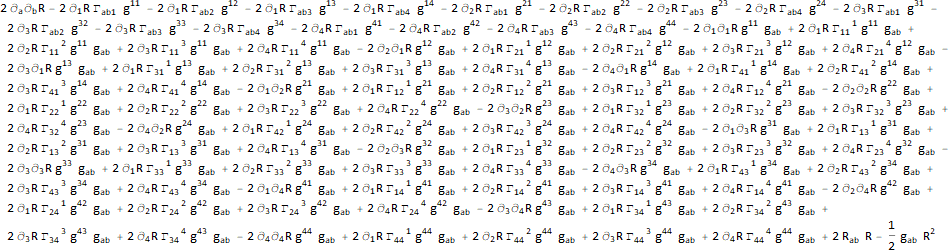

In [6]:
hExpr = SumDum[{1, 4}, %]

Robertson-Walker 시공간:

In [7]:
coSys = {x, y, z, t};
metric = {{a[t]^2, 0, 0, 0},
           {0, a[t]^2, 0, 0},
           {0, 0, a[t]^2, 0},
           {0, 0, 0, -1}};

In [9]:
InitCTensor[coSys, metric, RicciCD -> True]

초기화 설정 후의 결과값들을 출력한다:

4           2
   5 a'[t]    12 a'[t]  a''[t]         2            (3)              (4)
6 (-------- - ---------------- + a''[t]  + 4 a'[t] a   [t] + 2 a[t] a   [t])
        2           a[t]
    a[t]
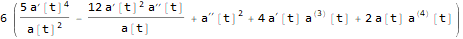

In [10]:
hExpr /. {la -> -1, lb -> -1} // Simplify

4           2
   5 a'[t]    12 a'[t]  a''[t]         2            (3)              (4)
6 (-------- - ---------------- + a''[t]  + 4 a'[t] a   [t] + 2 a[t] a   [t])
        2           a[t]
    a[t]
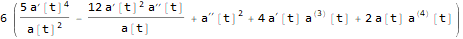

In [11]:
hExpr /. {la -> -2, lb -> -2} // Simplify

In [12]:
hExpr /. {la -> -2, lb -> -1}

0

4               2              2       2         2        (3)
-18 (-5 a'[t]  + 2 a[t] a'[t]  a''[t] + a[t]  a''[t]  + 2 a[t]  a'[t] a   [t])
------------------------------------------------------------------------------
                                        4
                                    a[t]
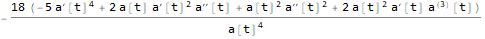

In [13]:
hExpr /. {la -> -4, lb -> -4} // Simplify

## 4.2 Coordinate Transformation of Tensors

### 4.2.1 Ttransform: Syntax and Explanation

변환 전의 좌표계를 `coSys`, 변환 후의 좌표계를 `newCoSys`라고 하자. 이러한 좌표 변환에 따른 텐서 성분의 변화를 구하려면 `Ttransform` 함수를 사용한다.

변환 전의 텐서 $oldT$의 성분을 알면서 변환 후의 텐서 $newT$의 성분을 구하려면
```
  Ttransform[oldT[la/ua,...], newT, coSys, newCoSys]
```
반대로, 변환 후의 텐서 $newT$의 성분을 알면서 변환 전의 텐서 $oldT$의 성분을 구하려면
```
  Ttransform[oldT, newT[la/ua,...], coSys, newCoSys]
```

### 4.2.2 Four Examples

### 4.2.3 Example One: Familiar Calculation

삼차원에서 구형 좌표계로부터 직교 좌표계로 변환할 때 메트릭 $g_{ab}$의 성분 변환:

In [2]:
coSys = {r, \[Theta], \[Phi]};
newCoSys = {x, y, z};

In [4]:
rightRule = {x -> r Sin[\[Theta]] Cos[\[Phi]],
              y -> r Sin[\[Theta]] Sin[\[Phi]],
              z -> r Cos[\[Theta]]}

{x -> r Cos[ϕ] Sin[θ], y -> r Sin[θ] Sin[ϕ], z -> r Cos[θ]}

In [5]:
Tdefine[{oldg, newg}, "ba"]

직교 좌표계에서의 $newg_{ab}$ 성분은 알고 있다:

In [6]:
SetComponents[newg[la, lb], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}]

구형 좌표계에서의 $oldg_{ab}$를 구한다:

In [7]:
Ttransform[oldg, newg[la, lb], coSys, newCoSys /. rightRule]

결과 출력:

In [8]:
Table[oldg[-i, -j], {i, 3}, {j, 3}] // Simplify

2              2       2
{{1, 0, 0}, {0, r , 0}, {0, 0, r  Sin[θ] }}

### 4.2.4 Example Two: Simple Shear

좌표계 `coSys`는 물체에 '고정된' 경사 좌표계이고, `newCoSys`는 물체 외부의 직교 좌표계이다:

In [9]:
coSys = {x, y, z}; newCoSys = {x + K y, y, z};

직교 좌표계에서의 메트릭:

In [10]:
SetComponents[newg[la, lb], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}]

좌표계 `coSys`에서의 메트릭 $oldg_{ab}$를 구한다:

In [11]:
Ttransform[oldg, newg[la, lb], coSys, newCoSys]

1        K        0

              2
K        1 + K    0


0        0        1
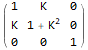

In [12]:
Table[oldg[-i, -j], {i, 3}, {j, 3}] // MatrixForm

좌표계 `coSys`에서의 메트릭 $oldg^{ab}$를 구한다:

In [13]:
SetComponents[newg[ua, ub], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}];

In [14]:
Ttransform[oldg, newg[ua, ub], coSys, newCoSys]

2
1 + K    -K       0


-K       1        0


0        0        1
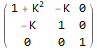

In [15]:
Table[oldg[i, j], {i, 3}, {j, 3}] // MatrixForm

### 4.2.5 Example Three: Special Relativity

$x$ 방향으로 운동하는 관성 좌표계의 로렌츠 변환:

In [16]:
gamma = (1 - v^2/c^2)^(-1/2);

In [17]:
coSys = {x, y, z, t};
newCoSys = {gamma (x - v t), y, z, gamma (t - v/c^2 x)};

전자기장 $F^{ab}$의 'boost' 좌표계에서의 표현을 구한다:

In [22]:
Tdefine[{F, newF}, "-ba"]

In [23]:
Ttransform[F[ua, ub], newF, coSys, newCoSys]

F[1, 2] + v F[2, 4]  F[1, 3] + v F[3, 4]
{{0, -------------------, -------------------, F[1, 4]}, 
                  2                    2
                 v                    v
        Sqrt[1 - --]         Sqrt[1 - --]
                  2                    2
                 c                    c
 
                                                    2
     -F[1, 2] - v F[2, 4]              v F[1, 2] + c  F[2, 4]
>   {--------------------, 0, F[2, 3], ----------------------}, 
                   2                                   2
                  v                        2          v
         Sqrt[1 - --]                     c  Sqrt[1 - --]
                   2                                   2
                  c                                   c
 
                                                     2
     -F[1, 3] - v F[3, 4]               v F[1, 3] + c  F[3, 4]
>   {--------------------, -F[2, 3], 0, ----------------------}, 
                   2                                    2
                  v                         2          v
         Sqrt[1 - --]                      c  Sqrt[1 - --]
                   2                                    2
                  c                                    c
 
                               2                          2
               -(v F[1, 2]) - c  F[2, 4]  -(v F[1, 3]) - c  F[3, 4]
>   {-F[1, 4], -------------------------, -------------------------, 0}}
                                 2                          2
                     2          v               2          v
                    c  Sqrt[1 - --]            c  Sqrt[1 - --]
                                 2                          2
                                c                          c
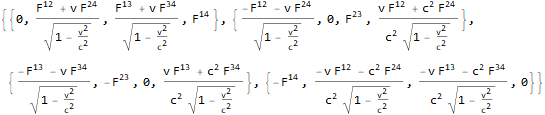

In [29]:
Table[newF[i, j], {i, 1, 4}, {j, 1, 4}] // TindexSort // Simplify

### 4.2.6 Example Four: General Relativity -- Kruskal Coordinates

슈바르츠실트 블랙홀에서 구형 좌표계로부터 Kruskal 좌표계로의 변환:

r/(4 M)            r         t     r/(4 M)            r         t
{E        Sqrt[-1 + ---] Cosh[---], E        Sqrt[-1 + ---] Sinh[---]}
                    2 M       4 M                      2 M       4 M
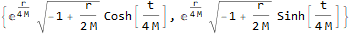

In [30]:
coSys = {r, t};
newCoSys = {Sqrt[r/(2 M) - 1] E^(r/(4 M)) Cosh[t/(4 M)],
             Sqrt[r/(2 M) - 1] E^(r/(4 M)) Sinh[t/(4 M)]}

Kruskal 좌표계에서의 메트릭 $newg_{ab}$를 구한다:

In [32]:
Tdefine[{g, newg}, "ba"]

In [33]:
SetComponents[g[la, lb],
               {{1/(1 - (2 M)/r), 0}, {0, -(1 - (2 M)/r)}}]

성분 표현의 단순화 명령에 `Simplify`를 옵션으로 사용한다:

In [34]:
Ttransform[g[la, lb], newg, coSys, newCoSys, Simplify]

3                    3
    32 M                -32 M
{{----------, 0}, {0, ----------}}
   r/(2 M)             r/(2 M)
  E        r          E        r
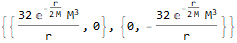

In [35]:
Table[newg[-i, -j], {i, 2}, {j, 2}]

따라서 슈바르츠실트 블랙홀의 사건지평면 $r_h = 2M$이 실제 특이점이 아니다.

## 4.3 Using More Than One Type of Index

### 4.3.1 Types of Indices

반대칭 텐서를 정의한다:

In [36]:
Tdefine[t, "-ba"]

텐서 인덱스의 자동적 조정을 끈다:

In [37]:
Off[AutoFlag]

In [38]:
t[la, lb] t[ua, ub]

t[la, lb] t[ua, ub]

Contracted 인덱스를 더미 인덱스로 바꾼다 (내부적으로 더미 인덱스는 유일하도록 유지된다):

In [39]:
% // Dum

t[l$1, l$2] t[u$1, u$2]

반대칭 텐서의 trace는 `0`이다:

In [40]:
t[la, ua]

t[la, ua]

In [41]:
% // Tsimplify

0

`mTensor`에서 기본적으로 준비된 인덱스는 Latin 계열의 문자로 구성된다:

{la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, lt, lu, lv, 
 
>   lw, lx, ly, lz, ua, ub, uc, ud, ue, uf, ug, uh, ui, uj, uk, ul, um, un, uo, up, uq, 
 
>   ur, us, ut, uu, uv, uw, ux, uy, uz}
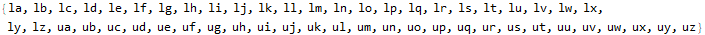

In [42]:
ShowIndices[]

따라서 사용할 수 있는 인덱스는 영문 알파벳의 개수와 같다. 그러나 이것이 충분치 않으면 사용할 수 있는 인덱스를 더할 수 있다:

In [74]:
AddIndices[{A, B, C, D, E}]

{la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, lt, lu, lv, 
 
>   lw, lx, ly, lz, lA, lB, lC, lD, lE, ua, ub, uc, ud, ue, uf, ug, uh, ui, uj, uk, ul, 
 
>   um, un, uo, up, uq, ur, us, ut, uu, uv, uw, ux, uy, uz, uA, uB, uC, uD, uE}
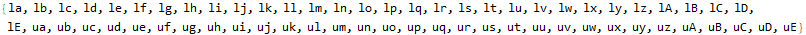

In [75]:
ShowIndices[]

In [76]:
t[lA, uB]

t[lA, uB]

새로운 종류의 인덱스를 정의할 수도 있다:

In [43]:
DefineKind["b" <> # & /@ Alphabet[], Bar]

{lba, lbb, lbc, lbd, lbe, lbf, lbg, lbh, lbi, lbj, lbk, lbl, lbm, lbn, lbo, lbp, lbq, 
 
>   lbr, lbs, lbt, lbu, lbv, lbw, lbx, lby, lbz, uba, ubb, ubc, ubd, ube, ubf, ubg, ubh, 
 
>   ubi, ubj, ubk, ubl, ubm, ubn, ubo, ubp, ubq, ubr, ubs, ubt, ubu, ubv, ubw, ubx, uby, 
 
>   ubz}
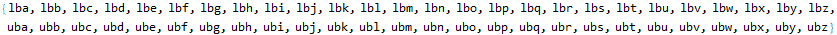

In [44]:
ShowIndices[Bar]

인덱스 계열을 Bundle 개념으로 간주할 수 있다. 예를 들면, Latin 계열의 인덱스에 대한 메트릭은 $g_{ab}$이고, 다른 인덱스 계열의 메트릭은 $\eta_{\bar{a} \bar{b}}$로 설정할 수 있다.

Bar 인덱스를 위한 메트릭을 정의한다:

In [45]:
DefineMetric[gBar, Bar]

처음 두 개의 인덱스는 Bar 계열, 나머지 두 개의 인덱스는 Latin 계열인 텐서를 정의한다. 각각의 계열에서 인덱스는 대칭이다:

In [46]:
Tdefine[t22[lba, lbb, lc, ld], "+bacd+abdc"]

In [47]:
t22[lba, lbb, le, lf]

t22[lba, lbb, le, lf]

In [48]:
t22[lba, uba, le, ue]

t22[lba, uba, le, ue]

Contracted 인덱스를 더미 인덱스로 바꾼다. 더미 인덱스는 내부적으로 유일하게 유지됨을 기억하자:

In [49]:
% // Dum

t22[l%1, u%1, l$3, u$3]

In [50]:
t22[lba, lbb, la, lb] t22[uba, ubb, ua, ub]

t22[lba, lbb, la, lb] t22[uba, ubb, ua, ub]

In [51]:
% // Dum

t22[l%2, l%3, l$4, l$5] t22[u%2, u%3, u$4, u$5]

반대칭 텐서 $t_{ab}$와 대칭 텐서 $t_{\bar{a}\bar{b}}^{\ \ \ ab}$의 텐서곱으로 Latin 계열의 인덱스가 contracted 되었으므로 `0`이다.

In [52]:
t[la, lb] t22[lba, lbb, ua, ub]

t[la, lb] t22[lba, lbb, ua, ub]

In [53]:
% // Tsimplify

0

내부적으로 유지되는 더미 인덱스로부터 정규 인덱스로의 변환이 자동적으로 이루어지도록 한다:

In [54]:
On[AutoFlag]  (* default *)

In [55]:
t22[lba, lbb, ua, ub] t22[ubb, ubc, la, lc] t22[uba, lbc, lb, uc] + 
 t22[lba, lbb, ua, ub] t22[uba, ubc, lb, lc] t22[ubb, lbc, la, uc]

t22[lba, lbb, ua, ub] t22[uba, ubc, lb, lc] t22[ubb, lbc, la, uc] + 
 
>   t22[lba, lbb, ua, ub] t22[uba, lbc, lb, uc] t22[ubb, ubc, la, lc]

In [56]:
% // Tsimplify

2 t22[lba, lbb, la, lb] t22[uba, lbc, ua, lc] t22[ubb, ubc, ub, uc]

### 4.3.2 Tests and Commands for Various Types of Indices

새로운 종류의 인덱스를 정의한다:

In [57]:
DefineKind["d" <> # & /@ Alphabet[], Dot]

{lda, ldb, ldc, ldd, lde, ldf, ldg, ldh, ldi, ldj, ldk, ldl, ldm, ldn, ldo, ldp, ldq, 
 
>   ldr, lds, ldt, ldu, ldv, ldw, ldx, ldy, ldz, uda, udb, udc, udd, ude, udf, udg, udh, 
 
>   udi, udj, udk, udl, udm, udn, udo, udp, udq, udr, uds, udt, udu, udv, udw, udx, udy, 
 
>   udz}
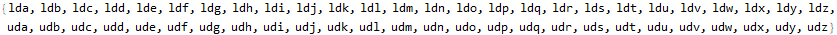

In [58]:
ShowIndices[Dot]

새로운 인덱스에도 적용되는 여러 가지의 인덱스 관련 함수들을 사용해 보자:

In [59]:
DnIndexQ /@ {la, lba, lda, ua, uba, uda}

{True, True, True, False, False, False}

In [60]:
UpIndexQ /@ {la, lba, lda, ua, uba, uda}

{False, False, False, True, True, True}

In [61]:
KindIndexQ[Latin][#] & /@ {la, lba, lda, ua, uba, uda}

{True, False, False, True, False, False}

In [62]:
KindIndexQ[Bar][#] & /@ {la, lba, lda, ua, uba, uda}

{False, True, False, False, True, False}

In [63]:
KindIndexQ[Dot][#] & /@ {la, lba, lda, ua, uba, uda}

{False, False, True, False, False, True}

In [64]:
{PairIndexQ[la, ua], PairIndexQ[lba, uba], PairIndexQ[lda, uda]}

{True, True, True}

In [65]:
ToUpIndex /@ {la, lba, lda}

{ua, uba, uda}

In [66]:
ToDnIndex /@ {ua, uba, uda}

{la, lba, lda}

In [67]:
FlipIndex /@ {la, ud, lc, uf, lba, ubd, lbc, ubf}

{ua, ld, uc, lf, uba, lbd, ubc, lbf}

텐서 표현의 인덱스를 추출하는 함수 `findIndices`는 내부적으로 사용된다:

In [68]:
Tdefine[s[lba, lbb, la, lb]]; Tdefine[t[lda, ldb, la, lb]]

In [69]:
s[lba, uba, lc, ld] t[udd, ldd, uc, ue]

s[lba, uba, lc, ld] t[udd, ldd, uc, ue]

In [70]:
indexList = mTensor`Private`findIndices[%]

{lba, uba, lc, ld, udd, ldd, uc, ue}

In [71]:
Select[indexList, KindIndexQ[Bar]]

{lba, uba}

In [72]:
Select[indexList, KindIndexQ[Dot]]

{udd, ldd}

In [73]:
Select[indexList, KindIndexQ[Latin]]

{lc, ld, uc, ue}

### 4.3.3 Transformation Rules with Multiple Types of Indices

`Mathematica`를 재시작하고, `mTensor`를 다시 로드한다:

In [1]:
<< mTensor`

양-밀스 게이지장 이론을 위해 새로운 인덱스 계열을 정의하고, 기본 계열로 설정하자:

In [2]:
DefineKind[Alphabet["Greek"], Greek]

In [3]:
SetDefaultKind[Greek]

양-밀스 게이지장 $A_\mu^{\ a}$와 $F_{\mu\nu}^{\ \ \ a}$와 구조상수 $f_{abc}$를 정의하자:

In [4]:
Tdefine[YMA, "A", "ab", {Greek, Latin}]
YMA[l\[Mu], ua]

YMA[lμ, ua]

In [6]:
Tdefine[YMF, "F", "-bac", {Greek, Greek, Latin}]
YMF[l\[Mu], l\[Nu], ua]

YMF[lμ, lν, ua]

In [8]:
Tdefine[YMf, "f", "3-", Latin]
YMf[la, lb, lc]

YMf[la, lb, lc]

Latin 계열을 위한 메트릭을 정의한다:

In [10]:
DefineMetric[YMg, "\[Delta]", Latin]

구조 상수와 게이지장에 대한 규칙을 설정한다:

In [11]:
structProdRule = RuleUnique[
    YMf[a_, b_, e_] YMf[c_, d_, f_],
    YMg[a, c] YMg[b, d] - YMg[a, d] YMg[b, c],
    PairIndexQ[e, f]]

YMf[a_, b_, e_] YMf[c_, d_, f_] :> 
 
>   DumFresh[-(YMg[a, d] YMg[b, c]) + YMg[a, c] YMg[b, d]] /; PairIndexQ[e, f]

In [12]:
YMf[la, lb, le] YMf[lc, ld, ue] /. structProdRule

-(YMg[la, ld] YMg[lb, lc]) + YMg[la, lc] YMg[lb, ld]

In [13]:
fieldRule = 
 RuleUnique[YMF[a_, b_, c_], 
  BD[a, YMA[b, c]] - BD[b, YMA[a, c]] + 
   e YMf[lp, lq, c] YMA[a, up] YMA[b, uq]]

YMF[a_, b_, c_] :> 
 
>   DumFresh[BD[a, YMA[b, c]] - BD[b, YMA[a, c]] + 
 
>     e YMA[a, u$1] YMA[b, u$2] YMf[l$1, l$2, c]]

In [14]:
YMF[l\[Mu], l\[Nu], uc] /. fieldRule

BD[lμ, YMA[lν, uc]] - BD[lν, YMA[lμ, uc]] + e YMA[lμ, ua] YMA[lν, ub] YMf[la, lb, uc]

게이지장의 불변량:

In [15]:
Metricg[u\[Mu], u\[Alpha]] Metricg[u\[Nu], u\[Beta]] YMF[l\[Mu], 
  l\[Nu], ua] YMF[l\[Alpha], l\[Beta], la]

Metricg[uμ, uα] Metricg[uν, uβ] YMF[lα, lβ, la] YMF[lμ, lν, ua]

BD[lα, YMA[lβ, la]] BD[lμ, YMA[lν, ua]] Metricg[uμ, uα] Metricg[uν, uβ] - 
 
>   BD[lβ, YMA[lα, la]] BD[lμ, YMA[lν, ua]] Metricg[uμ, uα] Metricg[uν, uβ] - 
 
>   BD[lα, YMA[lβ, la]] BD[lν, YMA[lμ, ua]] Metricg[uμ, uα] Metricg[uν, uβ] + 
 
>   BD[lβ, YMA[lα, la]] BD[lν, YMA[lμ, ua]] Metricg[uμ, uα] Metricg[uν, uβ] + 
 
>   e BD[lμ, YMA[lν, ua]] Metricg[uμ, uα] Metricg[uν, uβ] YMA[lα, ub] YMA[lβ, uc] 
 
>    YMf[lb, lc, la] - e BD[lν, YMA[lμ, ua]] Metricg[uμ, uα] Metricg[uν, uβ] YMA[lα, ub] 
 
>    YMA[lβ, uc] YMf[lb, lc, la] + e BD[lα, YMA[lβ, la]] Metricg[uμ, uα] Metricg[uν, uβ] 
 
>    YMA[lμ, ub] YMA[lν, uc] YMf[lb, lc, ua] - 
 
>   e BD[lβ, YMA[lα, la]] Metricg[uμ, uα] Metricg[uν, uβ] YMA[lμ, ub] YMA[lν, uc] 
 
                        2
>    YMf[lb, lc, ua] + e  Metricg[uμ, uα] Metricg[uν, uβ] YMA[lα, ub] YMA[lβ, uc] 
 
>    YMA[lμ, ud] YMA[lν, ue] YMf[lb, lc, la] YMf[ld, le, ua]
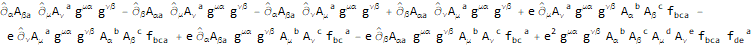

In [16]:
% /. fieldRule

-(BD[uβ, YMA[lμ, ua]] BD[uμ, YMA[lβ, la]]) - BD[uα, YMA[lν, ua]] BD[uν, YMA[lα, la]] + 
 
>   BD[lν, YMA[lμ, ua]] BD[uν, YMA[lα, la]] Metricg[uμ, uα] + 
 
>   BD[lμ, YMA[lν, ua]] BD[uμ, YMA[lβ, la]] Metricg[uν, uβ] + 
 
>   e BD[lμ, YMA[lν, ua]] YMA[uμ, ub] YMA[uν, uc] YMf[lb, lc, la] - 
 
>   e BD[lν, YMA[lμ, ua]] YMA[uμ, ub] YMA[uν, uc] YMf[lb, lc, la] + 
 
>   e BD[lα, YMA[lβ, la]] YMA[uα, ub] YMA[uβ, uc] YMf[lb, lc, ua] - 
 
>   e BD[lβ, YMA[lα, la]] YMA[uα, ub] YMA[uβ, uc] YMf[lb, lc, ua] + 
 
     2
>   e  YMA[lμ, ud] YMA[lν, ue] YMA[uμ, ub] YMA[uν, uc] YMf[lb, lc, la] YMf[ld, le, ua]
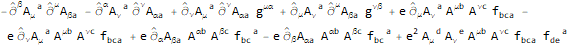

In [17]:
% // Absorbg

In [18]:
% // Tsimplify

-2 BD[uα, YMA[lβ, la]] BD[uβ, YMA[lα, ua]] + 
 
>   2 BD[lα, YMA[lβ, ua]] BD[uα, YMA[lγ, la]] Metricg[uγ, uβ] + 
 
>   2 e BD[lα, YMA[lβ, ua]] YMA[uα, lb] YMA[uβ, lc] YMf[ub, uc, la] + 
 
>   2 e BD[lα, YMA[lβ, la]] YMA[uα, lb] YMA[uβ, lc] YMf[ub, uc, ua] + 
 
     2
>   e  YMA[lα, la] YMA[lβ, lb] YMA[uα, lc] YMA[uβ, ld] YMf[ua, ub, le] YMf[uc, ud, ue]

In [19]:
% /. structProdRule

-2 BD[uα, YMA[lβ, la]] BD[uβ, YMA[lα, ua]] + 
 
>   2 BD[lα, YMA[lβ, ua]] BD[uα, YMA[lγ, la]] Metricg[uγ, uβ] + 
 
>   2 e BD[lα, YMA[lβ, ua]] YMA[uα, lb] YMA[uβ, lc] YMf[ub, uc, la] + 
 
>   2 e BD[lα, YMA[lβ, la]] YMA[uα, lb] YMA[uβ, lc] YMf[ub, uc, ua] - 
 
     2
>   e  YMA[lα, la] YMA[lβ, lb] YMA[uα, lc] YMA[uβ, ld] YMg[ua, ud] YMg[ub, uc] + 
 
     2
>   e  YMA[lα, la] YMA[lβ, lb] YMA[uα, lc] YMA[uβ, ld] YMg[ua, uc] YMg[ub, ud]

In [20]:
Absorb[%, YMg]

-2 BD[uα, YMA[lβ, la]] BD[uβ, YMA[lα, ua]] + 
 
>   2 BD[lα, YMA[lβ, ua]] BD[uα, YMA[lγ, la]] Metricg[uγ, uβ] - 
 
     2
>   e  YMA[lα, la] YMA[lβ, lb] YMA[uα, ub] YMA[uβ, ua] + 
 
     2
>   e  YMA[lα, la] YMA[lβ, lb] YMA[uα, ua] YMA[uβ, ub] + 
 
>   2 e BD[lα, YMA[lβ, ua]] YMA[uα, lb] YMA[uβ, lc] YMf[ub, uc, la] + 
 
>   2 e BD[lα, YMA[lβ, la]] YMA[uα, lb] YMA[uβ, lc] YMf[ub, uc, ua]

In [21]:
% // Tsimplify

-2 BD[uα, YMA[lβ, la]] BD[uβ, YMA[lα, ua]] + 
 
>   2 BD[lα, YMA[lβ, ua]] BD[uα, YMA[lγ, la]] Metricg[uγ, uβ] - 
 
     2
>   e  YMA[lα, la] YMA[lβ, ua] YMA[uα, lb] YMA[uβ, ub] + 
 
     2
>   e  YMA[lα, la] YMA[lβ, lb] YMA[uα, ua] YMA[uβ, ub] + 
 
>   2 e BD[lα, YMA[lβ, ua]] YMA[uα, lb] YMA[uβ, lc] YMf[ub, uc, la] + 
 
>   2 e BD[lα, YMA[lβ, la]] YMA[uα, lb] YMA[uβ, lc] YMf[ub, uc, ua]

위의 표현에서 $\hat{\partial}_\alpha \delta_{ab} = 0$이므로 마지막 두 개의 항은 같은 표현이다.

In [22]:
SetDefaultKind[Latin]  (* default *)

### 4.3.4 Warnings about Using `Kdelta`

### 4.3.5 Pauli Spin Matrices

`Mathematica`를 재시작하고, `mTensor`를 다시 로드한다:

In [1]:
<< mTensor`

새로운 인덱스 계열을 도입한다:

In [2]:
DefineKind[ToUpperCase /@ Alphabet[], Capital]

{lA, lB, lC, lD, lE, lF, lG, lH, lI, lJ, lK, lL, lM, lN, lO, lP, lQ, lR, lS, lT, lU, lV, 
 
>   lW, lX, lY, lZ, uA, uB, uC, uD, uE, uF, uG, uH, uI, uJ, uK, uL, uM, uN, uO, uP, uQ, 
 
>   uR, uS, uT, uU, uV, uW, uX, uY, uZ}
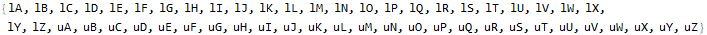

In [3]:
ShowIndices[Capital]

파울리 시그마 행렬의 인덱스 표기를 위한 텐서를 정의한다:

In [4]:
Tdefine[sigma[lA, uB, ua], "\[Sigma]", "abc"];
sigma[lA, uB, ua]

sigma[lA, uB, ua]

3차원 유클리드 공간의 메트릭을 설정한다:

In [6]:
MakeConstantMetric[{1, 1, 1}]

시그마 행렬의 곱셈 공식:
$$
  \sigma_a \sigma_b = \delta_{ab} + i \epsilon_{abc} \sigma_c
$$

In [7]:
sigmaRule = 
 RuleUnique[sigma[A_, B_, a_] sigma[D_, C_, b_], 
  Metricg[a, b] Kdelta[A, C] + 
   I Epsilon[a, b, uc] sigma[A, C, lc], PairIndexQ[B, D]]

sigma[A_, B_, a_] sigma[D_, C_, b_] :> 
 
>   DumFresh[Kdelta[A, C] Metricg[a, b] + I Epsilon[a, b, u$1] sigma[A, C, l$1]] /; 
 
>    PairIndexQ[B, D]

In [8]:
sigma[lA, uB, 1] sigma[lB, uC, 1]

sigma[lA, uB, 1] sigma[lB, uC, 1]

In [9]:
% /. sigmaRule

Kdelta[lA, uC] + I Epsilon[1, 1, ua] sigma[lA, uC, la]

In [10]:
% // TindexSort

Kdelta[lA, uC]

In [11]:
sigma[lA, uB, 1] sigma[lB, uC, 2]

sigma[lA, uB, 1] sigma[lB, uC, 2]

In [12]:
% /. sigmaRule

I Epsilon[1, 2, ua] sigma[lA, uC, la]

In [13]:
SumDum[%] // TindexSort

I sigma[lA, uC, -3]

In [14]:
sigma[lA, uB, 2] sigma[lB, uC, 1]

sigma[lA, uB, 2] sigma[lB, uC, 1]

In [15]:
% /. sigmaRule

I Epsilon[2, 1, ua] sigma[lA, uC, la]

In [16]:
SumDum[%] // TindexSort

-I sigma[lA, uC, -3]

In [17]:
Tdefine[{c, d}, 1]

In [18]:
c[la] sigma[lA, uB, ua] sigma[lB, uC, ub] d[lb]

c[la] d[lb] sigma[lA, uB, ua] sigma[lB, uC, ub]

In [19]:
% /. sigmaRule

c[la] d[lb] Kdelta[lA, uC] Metricg[ua, ub] + 
 
>   I c[la] d[lb] Epsilon[ua, ub, uc] sigma[lA, uC, lc]

In [20]:
% // SumDum

c[-3] d[-3] Kdelta[lA, uC] + c[-2] d[-2] Kdelta[lA, uC] + c[-1] d[-1] Kdelta[lA, uC] + 
 
>   I c[-1] d[-2] sigma[lA, uC, -3] - I c[-2] d[-1] sigma[lA, uC, -3] - 
 
>   I c[-1] d[-3] sigma[lA, uC, -2] + I c[-3] d[-1] sigma[lA, uC, -2] + 
 
>   I c[-2] d[-3] sigma[lA, uC, -1] - I c[-3] d[-2] sigma[lA, uC, -1]

In [21]:
ClearConstantMetric[]  (* default *)

### 4.3.6 Summing Expressions with Several Types of Indices

파울리 행렬:

In [28]:
sigmaMat[1] = {{0, 1}, {1, 0}};
sigmaMat[2] = {{0, -I}, {I, 0}};
sigmaMat[3] = {{1, 0}, {0, -1}};

In [31]:
sigma[i_Integer /; Negative[i], j_Integer /; Positive[j], 
  n_Integer] := sigmaMat[Abs[n]][[-i, j]]

In [32]:
sigma[lA, uB, 2] sigma[lB, uC, 3]

sigma[lA, uB, 2] sigma[lB, uC, 3]

In [33]:
SumDum[{lB, -1, -2}, %]

sigma[-1, uC, 3] sigma[lA, 1, 2] + sigma[-2, uC, 3] sigma[lA, 2, 2]

In [34]:
Table[%, {uC, 2}, {lA, -1, -2, -1}]

{{0, I}, {I, 0}}

In [35]:
sigmaMat[2] . sigmaMat[3]

{{0, I}, {I, 0}}

In [36]:
expr = Kdelta[la, ub] sigma[lA, uB, ua] sigma[lB, uC, lb]

sigma[lA, uB, ua] sigma[lB, uC, la]

In [37]:
SumDum[{la, -1, -2, -3}, {lB, -1, -2}, %]

sigma[-1, uC, -1] sigma[lA, 1, 1] + sigma[-1, uC, -2] sigma[lA, 1, 2] + 
 
>   sigma[-1, uC, -3] sigma[lA, 1, 3] + sigma[-2, uC, -1] sigma[lA, 2, 1] + 
 
>   sigma[-2, uC, -2] sigma[lA, 2, 2] + sigma[-2, uC, -3] sigma[lA, 2, 3]

In [38]:
Table[%, {uC, 2}, {lA, -1, -2, -1}] // MatrixForm

3   0

0   3

로렌츠 변환을 위해 민코프스키 시공간의 메트릭을 설정한다:

In [39]:
MakeConstantMetric[{-1, 1, 1, 1}]

새로운 인덱스 계열을 도입한다:

In [40]:
DefineKind[Alphabet["Greek"], Greek]

In [41]:
SetDefaultKind[Greek]

로렌츠 변환 행렬과 속도 벡터를 정의한다:

In [42]:
Tdefine[L[u\[Mu], l\[Nu]]];
Tdefine[v[ua]]

메트릭은 로렌츠 변환에 불변이다:

In [46]:
lorentzRule = 
 RuleUnique[L[a_, c_] L[b_, d_] Metricg[e_, f_],
             Metricg[c, d],
             (PairIndexQ[a, e] && PairIndexQ[b, f]) ||
             (PairIndexQ[a, f] && PairIndexQ[b, e])]

L[a_, c_] L[b_, d_] Metricg[e_, f_] :> 
 
>   DumFresh[Metricg[c, d]] /; 
 
>    (PairIndexQ[a, e] && PairIndexQ[b, f]) || (PairIndexQ[a, f] && PairIndexQ[b, e])

In [47]:
L[u\[Mu], l\[Rho]] L[u\[Nu], l\[Sigma]] Metricg[l\[Mu], l\[Nu]]

L[uμ, lρ] L[uν, lσ] Metricg[lμ, lν]

In [48]:
% /. lorentzRule

Metricg[lρ, lσ]

로렌츠 변환 규칙:

In [49]:
vRule = RuleUnique[L[a_, -1],
                    v[a] L[1, -1],
                    UpIndexQ[a] && KindIndexQ[Latin][a]]

L[a_, -1] :> DumFresh[L[1, -1] v[a]] /; UpIndexQ[a] && KindIndexQ[Latin][a]

In [50]:
L[ua, -1]

L[ua, -1]

In [51]:
% /. vRule

L[1, -1] v[ua]

메트릭 규칙:

In [52]:
g1Rule = {Metricg[-1, a_ /; KindIndexQ[Latin][a]] :> 0,
           Metricg[a_ /; KindIndexQ[Latin][a], -1] :> 0}

{Metricg[-1, a_ /; KindIndexQ[Latin][a]] :> 0, 
 
>   Metricg[a_ /; KindIndexQ[Latin][a], -1] :> 0}

In [53]:
{Metricg[-1, lb], Metricg[-1, l\[Mu]], Metricg[-1, -1]}

{Metricg[-1, lb], Metricg[-1, lμ], -1}

In [54]:
% /. g1Rule

{0, Metricg[-1, lμ], -1}

In [55]:
g2Rule = Metricg[a_ /; KindIndexQ[Latin][a],
                  b_ /; KindIndexQ[Latin][b]] :> Kdelta[a, b]

Metricg[a_ /; KindIndexQ[Latin][a], b_ /; KindIndexQ[Latin][b]] :> Kdelta[a, b]

In [56]:
Metricg[la, ub]

Metricg[la, ub]

In [57]:
% /. g2Rule

Kdelta[la, ub]

In [58]:
gRule = Flatten@{g1Rule, g2Rule};

In [59]:
expr = L[u\[Mu], -1] L[u\[Nu], -1] Metricg[l\[Mu], l\[Nu]]

L[uμ, -1] L[uν, -1] Metricg[lμ, lν]

In [60]:
expr /. lorentzRule

-1

In [61]:
SumDum[{l\[Mu], la, -1}, {l\[Nu], lb, -1}, expr]

2
-L[1, -1]  + L[1, -1] L[ub, -1] Metricg[-1, lb] + L[1, -1] L[ua, -1] Metricg[la, -1] + 
 
>   L[ua, -1] L[ub, -1] Metricg[la, lb]

In [62]:
% /. gRule

2
-L[1, -1]  + Kdelta[la, lb] L[ua, -1] L[ub, -1]

In [63]:
% /. vRule

2                          2
-L[1, -1]  + Kdelta[la, lb] L[1, -1]  v[ua] v[ub]

In [64]:
eq = % == -Lightc^2

2                          2                       2
-L[1, -1]  + Kdelta[la, lb] L[1, -1]  v[ua] v[ub] == -Lightc

Lightc
{{L[1, -1] -> -(------------------------------------)}, 
                Sqrt[1 - Kdelta[la, lb] v[ua] v[ub]]
 
                                Lightc
>   {L[1, -1] -> ------------------------------------}}
                 Sqrt[1 - Kdelta[la, lb] v[ua] v[ub]]
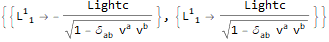

In [65]:
Solve[eq, L[1, -1]]

## 4.4 Manipulating Equations in MathTensor

## 4.5 Unit Systems, Constants, Sign Convections